In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers, models
from keras.models import Sequential, Model, load_model
from keras.layers import Reshape, Dense, Input
from sklearn.model_selection import train_test_split
import keras_tuner as kt
from keras.utils import plot_model
import pandas as pd

In [58]:
data_folder = "/home/sputnik/main/MyFolder/DL_Practice/prob1_data" 
output_file = data_folder + "/output.xlsx"
stress_folder = data_folder + "/stress"

In [59]:
X_df = pd.read_excel(output_file, header=None)

X_df = X_df.dropna(axis=0, how="all")
X_df = X_df.dropna(axis=1, how="all")

X = X_df.values.astype(float)

print("Shape of X:", X.shape)


Shape of X: (5000, 226)


In [60]:
num_samples = X.shape[0]

y = []

for i in range(num_samples):
    stress_file = stress_folder + "/stress_" + str(i) + ".txt"
    
    stress_data = np.loadtxt(stress_file)
    
    von_mises_stress = stress_data[:, 0]
    max_stress = np.max(von_mises_stress)
    
    y.append(max_stress)

y = np.array(y).reshape(-1, 1)

print("Shape of y:", y.shape)
print("Minimum max stress:", np.min(y))
print("Maximum max stress:", np.max(y))
print("Mean max stress:", np.mean(y))


Shape of y: (5000, 1)
Minimum max stress: 4412533.22285112
Maximum max stress: 43744146.8480609
Mean max stress: 9497545.137606278


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (4000, 226)
X_test: (1000, 226)
y_train: (4000, 1)
y_test: (1000, 1)


In [62]:
X_mean = np.mean(X_train, axis=0)
X_std = np.std(X_train, axis=0)
X_std[X_std == 0] = 1

y_mean = np.mean(y_train, axis=0)
y_std = np.std(y_train, axis=0)

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

y_train_scaled = (y_train - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std


In [ ]:

grid_rows, grid_cols = 11, 21
target_size = grid_rows * grid_cols  

pad_size = target_size - X_train_scaled.shape[1]

X_train_cnn = np.pad(X_train_scaled, ((0,0),(0,pad_size)), mode='constant', constant_values=0)
X_test_cnn  = np.pad(X_test_scaled,  ((0,0),(0,pad_size)), mode='constant', constant_values=0)

X_train_cnn = X_train_cnn.reshape(-1, grid_rows, grid_cols, 1)
X_test_cnn  = X_test_cnn.reshape(-1, grid_rows, grid_cols, 1)

print("X_train_cnn shape:", X_train_cnn.shape)  
print("X_test_cnn shape:",  X_test_cnn.shape)   

X_train_cnn shape: (4000, 11, 21, 1)
X_test_cnn shape: (1000, 11, 21, 1)


In [64]:
def r2metric(y_true, y_pred):
    ss_res = tf.reduce_sum(tf.square(y_true - y_pred))
    ss_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
    return 1 - ss_res / (ss_tot + tf.keras.backend.epsilon())


In [ ]:
def build_cnn(input_shape):
    inputs = Input(shape=input_shape)

    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(1, activation='linear')(x)
    
    model = Model(inputs, output)
    return model

cnn_model = build_cnn((grid_rows, grid_cols, 1))
cnn_model.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 11, 21, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 11, 21, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 11, 21, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 5, 10, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 5, 10, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 5, 10, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 2, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 2, 5, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 2, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177,665 (694.00 KB)

 Trainable params: 177,217 (692.25 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:

cnn_model.compile( optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='mse', metrics=['mape', r2metric])

callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=35, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=0.5, patience=10, min_lr=1e-6, verbose=1)
]

history = cnn_model.fit(
    X_train_cnn, y_train_scaled,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 1.1851 - mape: 349.5530 - r2metric: -0.3665 - val_loss: 1.0546 - val_mape: 232.5934 - val_r2metric: -0.0393 - learning_rate: 0.0010
Epoch 2/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.9073 - mape: 209.9217 - r2metric: 1.2476e-04 - val_loss: 1.1096 - val_mape: 308.9633 - val_r2metric: -0.0934 - learning_rate: 0.0010
Epoch 3/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.8630 - mape: 220.5820 - r2metric: 0.0407 - val_loss: 1.0134 - val_mape: 189.6241 - val_r2metric: -0.0029 - learning_rate: 0.0010
Epoch 4/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.6651 - mape: 269.0970 - r2metric: 0.2192 - val_loss: 0.8481 - val_mape: 222.9600 - val_r2metric: 0.1987 - learning_rate: 0.0010
Epoch 5/200
100/100 ━━━━━━━━━━━━━━━━━━━━ -0s -4018us/step - loss: 0.5784 - mape: 216.4745 - r2metric: 0.3178 - val_loss: 0.6294 - val_mape: 216.3319 - val_r2metric: 0.3190 - learning_rate: 0.0010
Epoch 6/200
100/100 ━━━━━━━━

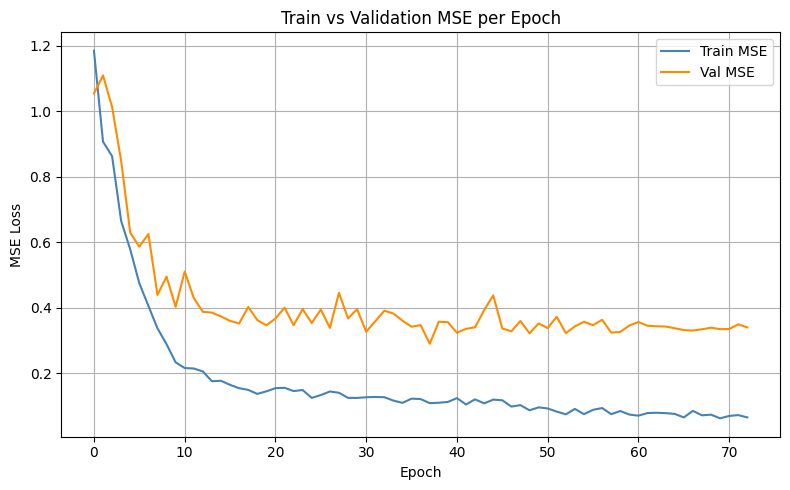

In [81]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'],     label='Train MSE', color='steelblue')
plt.plot(history.history['val_loss'], label='Val MSE',   color='darkorange')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Train vs Validation MSE per Epoch')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
train_loss,  train_mape, train_r2, = cnn_model.evaluate(X_train_cnn, y_train_scaled, verbose=0)
test_loss,   test_mape, test_r2  = cnn_model.evaluate(X_test_cnn,  y_test_scaled,  verbose=0)
print(f"Train MSE:{train_loss:.4f}")
print(f"Test MSE:{test_loss:.4f}")
print(f"Train R2:{train_r2:.4f}")
print(f"Test R2:{test_r2:.4f}")
print(f"Train MAPE:{train_mape:.2f}")
print(f"Test MAPE:{test_mape:.2f}")


Train MSE:0.1169
Test MSE:0.1931
Train R2:0.8596
Test R2:0.7396
Train MAPE:173.67
Test MAPE:125.52


In [83]:

y_pred_train = cnn_model.predict(X_train_cnn) * y_std + y_mean
y_pred_test  = cnn_model.predict(X_test_cnn)  * y_std + y_mean

train_mse_actual = np.mean((y_train - y_pred_train)**2)
test_mse_actual  = np.mean((y_test  - y_pred_test)**2)

train_mape_actual = np.mean(np.abs((y_train - y_pred_train) / y_train)) * 100
test_mape_actual  = np.mean(np.abs((y_test  - y_pred_test)  / y_test))  * 100

ss_res_train = np.sum((y_train - y_pred_train)**2)
ss_tot_train = np.sum((y_train - np.mean(y_train))**2)
train_r2_actual = 1 - (ss_res_train / ss_tot_train)

ss_res_test = np.sum((y_test - y_pred_test)**2)
ss_tot_test = np.sum((y_test - np.mean(y_test))**2)
test_r2_actual = 1 - (ss_res_test / ss_tot_test)

print(f"Train MSE:{train_mse_actual:.4f}")
print(f"Test  MSE:{test_mse_actual:.4f}")
print(f"Train R²:{train_r2_actual:.4f}")
print(f"Test  R²:{test_r2_actual:.4f}")
print(f"Train MAPE:{train_mape_actual:.2f}%")
print(f"Test  MAPE:{test_mape_actual:.2f}%")

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Train MSE:1900616977546.3931
Test  MSE:3139245883605.9287
Train R²:0.8831
Test  R²:0.7639
Train MAPE:10.28%
Test  MAPE:14.01%


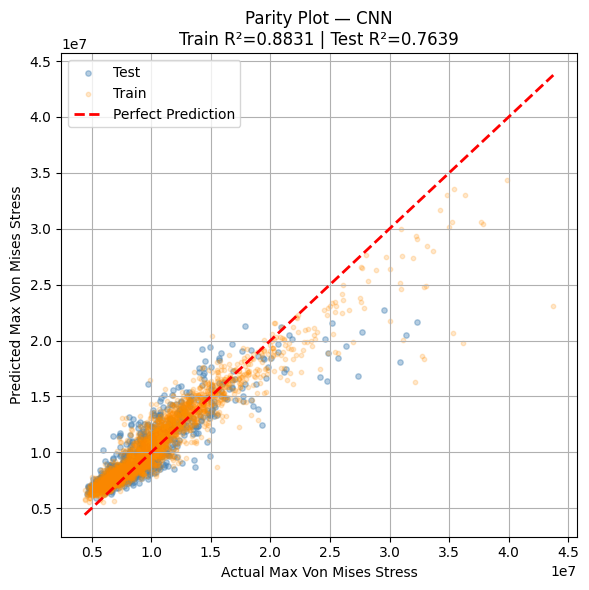

In [84]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test, alpha=0.4, s=15, color='steelblue', label='Test')
plt.scatter(y_train, y_pred_train, alpha=0.2, s=10, color='darkorange', label='Train')

mn = min(y_train.min(), y_test.min())
mx = max(y_train.max(), y_test.max())
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Max Von Mises Stress')
plt.ylabel('Predicted Max Von Mises Stress')
plt.title(f'Parity Plot — CNN\nTrain R²={train_r2_actual:.4f} | Test R²={test_r2_actual:.4f}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

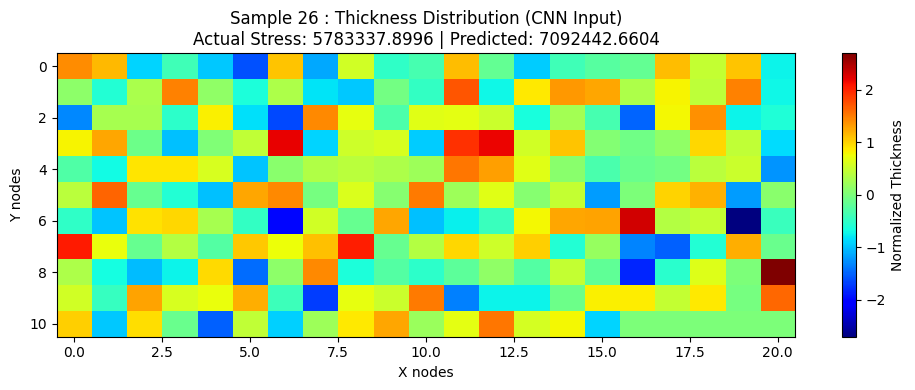

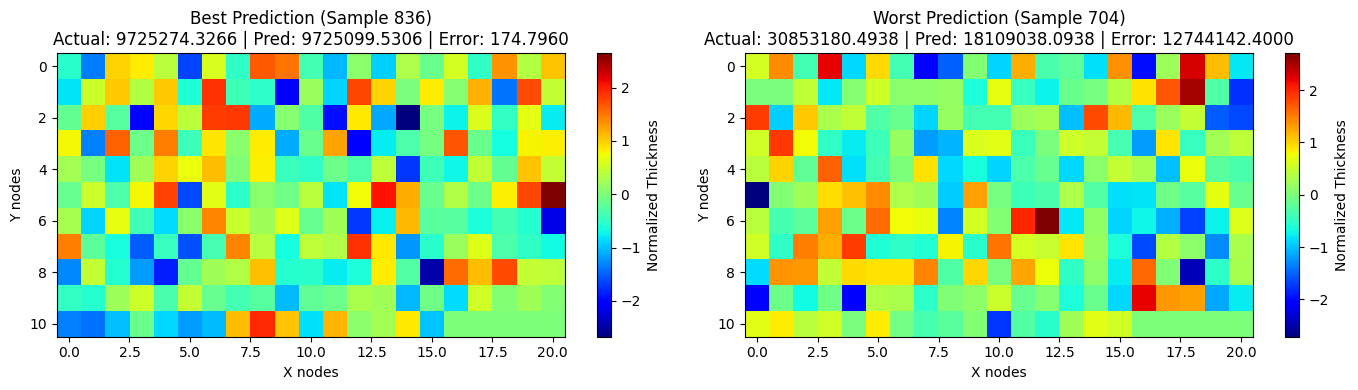

In [88]:

sample_idx = 26  
sample_input = X_test_cnn[sample_idx].reshape(grid_rows, grid_cols)

plt.figure(figsize=(10, 4))
plt.imshow(sample_input, cmap='jet', aspect='auto')
plt.colorbar(label='Normalized Thickness')
plt.title(f'Sample {sample_idx} : Thickness Distribution (CNN Input)\n'
          f'Actual Stress: {y_test[sample_idx][0]:.4f} | '
          f'Predicted: {y_pred_test[sample_idx][0]:.4f}')
plt.xlabel('X nodes')
plt.ylabel('Y nodes')
plt.tight_layout()
plt.show()

errors = np.abs(y_test - y_pred_test).flatten()
best_idx  = np.argmin(errors)
worst_idx = np.argmax(errors)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

im1 = axes[0].imshow(X_test_cnn[best_idx].reshape(grid_rows, grid_cols), 
                      cmap='jet', aspect='auto')
axes[0].set_title(f'Best Prediction (Sample {best_idx})\n'
                  f'Actual: {y_test[best_idx][0]:.4f} | '
                  f'Pred: {y_pred_test[best_idx][0]:.4f} | '
                  f'Error: {errors[best_idx]:.4f}')
axes[0].set_xlabel('X nodes')
axes[0].set_ylabel('Y nodes')
plt.colorbar(im1, ax=axes[0], label='Normalized Thickness')

im2 = axes[1].imshow(X_test_cnn[worst_idx].reshape(grid_rows, grid_cols), 
                      cmap='jet', aspect='auto')
axes[1].set_title(f'Worst Prediction (Sample {worst_idx})\n'
                  f'Actual: {y_test[worst_idx][0]:.4f} | '
                  f'Pred: {y_pred_test[worst_idx][0]:.4f} | '
                  f'Error: {errors[worst_idx]:.4f}')
axes[1].set_xlabel('X nodes')
axes[1].set_ylabel('Y nodes')
plt.colorbar(im2, ax=axes[1], label='Normalized Thickness')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


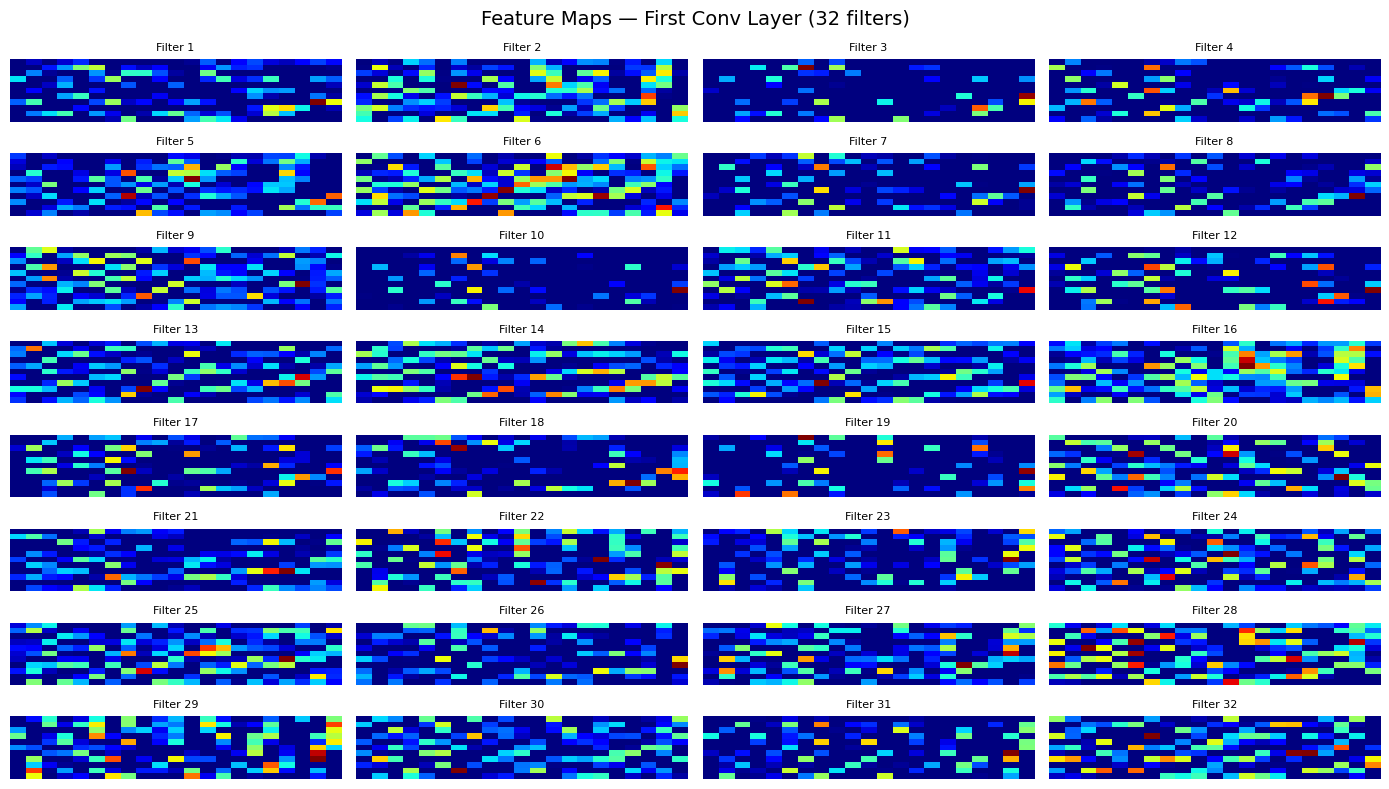

In [ ]:
feature_map_model = Model(inputs=cnn_model.input, outputs=cnn_model.layers[1].output)

sample = X_test_cnn[sample_idx:sample_idx+1]  # shape (1, 11, 21, 1)
feature_maps = feature_map_model.predict(sample)  # shape (1, 11, 21, 16)

fig, axes = plt.subplots(8, 4, figsize=(14, 8))
fig.suptitle('Feature Maps — First Conv Layer (32 filters)', fontsize=14)

for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps[0, :, :, i], cmap='jet', aspect='auto')
    ax.set_title(f'Filter {i+1}', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()
